# 复现当前 picture2 的绘图 notebook

这个 notebook 用于复现你当前 `results/picture2.svg` 的整体结构: 主曲线 + inset + 红色连接箭头。

使用说明:
1) 建议在 VSCode 中依次运行全部单元(或先 Run All)。
2) 若路径或环境不同, 只需修改配置单元中的变量。


In [55]:
from pathlib import Path
import json
import re
import sys
import importlib.util
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
def find_project_root(explicit_project_root: str = '') -> Path:
    """
    用途: 定位项目根目录(需同时包含 plot 和 results 子目录)。
    参数:
    - explicit_project_root: str, 用户手动指定路径, 为空时走自动探测。
    返回:
    - Path, 项目根目录绝对路径。
    """
    if explicit_project_root.strip() != '':
        root = Path(explicit_project_root).expanduser().resolve()
        if (root / 'plot').is_dir() and (root / 'results').is_dir():
            return root
        raise FileNotFoundError(f'手动指定路径不是项目根目录: {root}')
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.extend(cwd.parents)
    candidates.append(Path(r'D:/study/研究生/科研/VMC/HKJ_s/mfVMC'))
    for root in candidates:
        if (root / 'plot').is_dir() and (root / 'results').is_dir():
            return root
    raise FileNotFoundError('无法自动定位项目根目录, 请在配置单元设置 explicit_project_root。')
def build_k_grid_2d(lattice_x: int, lattice_y: int, center: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """
    用途: 构造二维动量点网格 KX, KY。
    参数:
    - lattice_x: int, x方向线性尺寸Lx。
    - lattice_y: int, y方向线性尺寸Ly。
    - center: bool, 是否将动量平移到[-pi, pi)区间。
    返回:
    - tuple[np.ndarray, np.ndarray], 网格化后的 KX 与 KY, shape均为 (Lx, Ly)。
    公式:
    - kx(i) = 2*pi*i/Lx, ky(j) = 2*pi*j/Ly
    """
    kx_values = 2.0 * np.pi / lattice_x * np.arange(lattice_x, dtype=float)
    ky_values = 2.0 * np.pi / lattice_y * np.arange(lattice_y, dtype=float)
    if center:
        kx_values = (kx_values + np.pi) % (2.0 * np.pi) - np.pi
        ky_values = (ky_values + np.pi) % (2.0 * np.pi) - np.pi
    grid_kx, grid_ky = np.meshgrid(kx_values, ky_values, indexing='ij')
    return grid_kx, grid_ky
def parse_ss_key(raw_key: str) -> tuple[int, int, int, int] | None:
    """
    用途: 解析 SS_all.json 中的键名。
    参数:
    - raw_key: str, 形如 'SS_x0_y0_x1_y1' 的键名。
    返回:
    - tuple[int, int, int, int] | None, 解析成功返回坐标元组, 失败返回None。
    """
    match_obj = re.fullmatch(r'SS_(\d+)_(\d+)_(\d+)_(\d+)', raw_key)
    if match_obj is None:
        return None
    return tuple(int(match_obj.group(index)) for index in range(1, 5))
def load_ss_terms(ss_all_json_path: Path, lattice_x: int, lattice_y: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """
    用途: 从 SS_all.json 读取(位移, 权重)项, 并统计参与格点数Nsite。
    参数:
    - ss_all_json_path: Path, SS_all.json 文件路径。
    - lattice_x: int, Lx。
    - lattice_y: int, Ly。
    返回:
    - tuple[np.ndarray, np.ndarray, np.ndarray, int]
      - delta_x_array: 每项的 (x0-x1)
      - delta_y_array: 每项的 (y0-y1)
      - ss_value_array: 每项对应的SS权重
      - n_site: 在键集合中出现过的格点总数
    """
    if not ss_all_json_path.is_file():
        raise FileNotFoundError(f'SS_all.json 不存在: {ss_all_json_path}')
    raw_dict = json.loads(ss_all_json_path.read_text(encoding='utf-8'))
    if not isinstance(raw_dict, dict):
        raise ValueError(f'SS_all.json 不是字典结构: {ss_all_json_path}')
    delta_x_list: list[float] = []
    delta_y_list: list[float] = []
    ss_value_list: list[float] = []
    site_flag = np.zeros((lattice_x, lattice_y), dtype=bool)
    for raw_key, raw_value in raw_dict.items():
        parsed = parse_ss_key(str(raw_key))
        if parsed is None:
            continue
        x0, y0, x1, y1 = parsed
        if not (0 <= x0 < lattice_x and 0 <= x1 < lattice_x and 0 <= y0 < lattice_y and 0 <= y1 < lattice_y):
            continue
        try:
            ss_value = float(raw_value)
        except (TypeError, ValueError):
            continue
        delta_x_list.append(float(x0 - x1))
        delta_y_list.append(float(y0 - y1))
        ss_value_list.append(ss_value)
        site_flag[x0, y0] = True
        site_flag[x1, y1] = True
    if len(ss_value_list) == 0:
        raise ValueError(f'SS_all.json 无可用SS项: {ss_all_json_path}')
    delta_x_array = np.asarray(delta_x_list, dtype=float)
    delta_y_array = np.asarray(delta_y_list, dtype=float)
    ss_value_array = np.asarray(ss_value_list, dtype=float)
    n_site = int(np.count_nonzero(site_flag))
    return delta_x_array, delta_y_array, ss_value_array, n_site
def compute_structure_factor_map(
    ss_all_json_path: Path,
    lattice_x: int,
    lattice_y: int,
    chunk_size: int = 32,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    用途: 由 SS_all.json 计算 S(q) 二维矩阵。
    参数:
    - ss_all_json_path: Path, SS_all.json 文件路径。
    - lattice_x: int, Lx。
    - lattice_y: int, Ly。
    - chunk_size: int, 分块计算q点数量, 降低峰值内存。
    返回:
    - tuple[np.ndarray, np.ndarray, np.ndarray]
      - grid_kx: np.ndarray, KX网格
      - grid_ky: np.ndarray, KY网格
      - sq_map: np.ndarray, S(q)矩阵
    公式:
    - S(q) = [2 * sum_{(r0,r1)} cos(q·(r0-r1)) * SS(r0,r1) + Nsite*0.75] / (Lx*Ly)^2
    """
    grid_kx, grid_ky = build_k_grid_2d(lattice_x=lattice_x, lattice_y=lattice_y, center=False)
    delta_x_array, delta_y_array, ss_value_array, n_site = load_ss_terms(
        ss_all_json_path=ss_all_json_path,
        lattice_x=lattice_x,
        lattice_y=lattice_y,
    )
    flat_kx = grid_kx.ravel()
    flat_ky = grid_ky.ravel()
    flat_sq = np.zeros_like(flat_kx, dtype=float)
    term_count = delta_x_array.shape[0]
    start_index = 0
    while start_index < flat_kx.shape[0]:
        end_index = min(start_index + int(chunk_size), flat_kx.shape[0])
        chunk_kx = flat_kx[start_index:end_index][:, None]
        chunk_ky = flat_ky[start_index:end_index][:, None]
        phase_matrix = chunk_kx * delta_x_array[None, :] + chunk_ky * delta_y_array[None, :]
        chunk_sum = (2.0 * np.cos(phase_matrix) * ss_value_array[None, :]).sum(axis=1)
        flat_sq[start_index:end_index] = chunk_sum
        start_index = end_index
    normalization = float((lattice_x * lattice_y) ** 2)
    flat_sq = (flat_sq + float(n_site) * 0.75) / normalization
    sq_map = flat_sq.reshape((lattice_x, lattice_y))
    print(f'[INFO] SS项数量 = {term_count}, Nsite = {n_site}, file = {ss_all_json_path.name}')
    return grid_kx, grid_ky, sq_map
def format_pi_label(value: float, max_denominator: int = 24) -> str:
    """
    用途: 将实数k值格式化为pi单位标签。
    参数:
    - value: float, k值。
    - max_denominator: int, 分母上限, 用于有理近似。
    返回:
    - str, LaTeX风格的pi标签字符串。
    """
    if np.isclose(value, 0.0):
        return '0'
    ratio = float(value / np.pi)
    fraction_value = Fraction(ratio).limit_denominator(max_denominator)
    numerator = fraction_value.numerator
    denominator = fraction_value.denominator
    if denominator == 1:
        if numerator == 1:
            return r'$\pi$'
        return rf'${numerator}\pi$'
    if numerator == 1:
        return rf'$\pi/{denominator}$'
    return rf'${numerator}\pi/{denominator}$'
def build_pi_ticks(max_k: float) -> tuple[list[float], list[str]]:
    """
    用途: 生成不超过max_k的pi单位坐标轴tick, 并补充末端离散k点刻度。
    参数:
    - max_k: float, 坐标轴上限。
    返回:
    - tuple[list[float], list[str]], tick位置和对应标签。
    """
    base_positions = [0.0, 0.5 * np.pi, np.pi, 1.5 * np.pi, 2.0 * np.pi]
    base_labels = ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
    tick_positions: list[float] = []
    tick_labels: list[str] = []
    for one_pos, one_label in zip(base_positions, base_labels):
        if one_pos <= max_k + 1e-10:
            tick_positions.append(float(one_pos))
            tick_labels.append(one_label)
    if len(tick_positions) == 0:
        tick_positions = [0.0]
        tick_labels = ['0']
    if abs(max_k - tick_positions[-1]) > 1e-6:
        tick_positions.append(float(max_k))
        tick_labels.append(format_pi_label(float(max_k)))
    return tick_positions, tick_labels
def apply_pi_ticks(axis_obj, max_k: float, show_y_ticklabels: bool) -> None:
    """
    用途: 将坐标轴tick设置为pi单位, 上限由max_k控制。
    参数:
    - axis_obj: matplotlib坐标轴对象。
    - max_k: float, 坐标轴上限。
    - show_y_ticklabels: bool, 是否显示y轴tick标签。
    返回:
    - None。
    """
    tick_positions, tick_labels = build_pi_ticks(max_k=max_k)
    axis_obj.set_xticks(tick_positions)
    axis_obj.set_xticklabels(tick_labels)
    axis_obj.set_yticks(tick_positions)
    if show_y_ticklabels:
        axis_obj.set_yticklabels(tick_labels)
print(f'python = {sys.executable}')
print(f'cwd    = {Path.cwd().resolve()}')


python = d:\software\anaconda3\envs\quspin\python.exe
cwd    = D:\study\研究生\科研\VMC\HKJ_s\mfVMC\plot


In [56]:
# =========================
# 配置区: 只改这里即可
# =========================
# 如果自动定位失败, 在这里填项目根目录绝对路径; 自动定位正常时保持空字符串
explicit_project_root = ''
project_root = find_project_root(explicit_project_root=explicit_project_root)
print(f'project_root = {project_root}')
# 主曲线数据源
l16_path = (project_root / 'results/L_16/J2_0.5_J3_1.25').resolve()
l18_path = (project_root / 'results/L_18/J2_0.5_J3_1.25').resolve()
l20_path = (project_root / 'results/L_20/auto_submit').resolve()
l12_path = (project_root / 'results/L_12/J2_0_J3_0').resolve()
hole_series_inputs = [
    f'L16:{l16_path}',
    f'L18:{l18_path}',
    f'L20:{l20_path}',
]
electron_series_inputs = [
    f'L12:{l12_path}',
]
# 三张S(q)配置: 依次对应左/中/右子图
# panel_tag用于主图阴影区和下方S(q)子图的编号映射
# doping_range表示该S(q)对应的doping区间 [xmin, xmax]
sq_panel_configs = [
    {
        'panel_tag': '(a)',
        'panel_label': 'S(q)',
        'ss_json_path': project_root / 'results/L_12/J2_0_J3_0/Ndefect9/logs/target_sz_1/SS_all.json',
        'lattice_size': 12,
        'doping_range': (-0.075, -0.049),
    },
    {
        'panel_tag': '(b)',
        'panel_label': 'S(q)',
        'ss_json_path': project_root / 'results/L_20/auto_submit/Ndefect18/logs/target_sz_2/SS_all.json',
        'lattice_size': 20,
        'doping_range': (0.035, 0.055),
    },
    {
        'panel_tag': '(c)',
        'panel_label': 'S(q)',
        'ss_json_path': project_root / 'results/L_20/auto_submit/Ndefect42/logs/target_sz_0/SS_all.json',
        'lattice_size': 20,
        'doping_range': (0.095, 0.115),
    },
]
# 输出文件
output_svg = project_root / 'results/picture2_from_notebook.svg'
output_pdf = project_root / 'results/picture2_from_notebook.pdf'
# 数据列配置
doping_col = 'doping'
ndefect_col = 'Ndefect'
mz_col = 'staggered_mz'
summary_name = 'summary_min_sector_staggered_mz_S_pi_pi.csv'
# S(q)计算参数
sq_chunk_size = 32
sq_level_count = 48
# =========================
# 科研绘图风格参数
# =========================
# 主图曲线: 使用色盲友好配色(Okabe-Ito家族)
curve_style_map = {
    'L=12': {'color': '#D55E00', 'marker': 'D'},
    'L=16': {'color': '#0072B2', 'marker': 'o'},
    'L=18': {'color': '#009E73', 'marker': 's'},
    'L=20': {'color': '#CC79A7', 'marker': '^'},
}
# 线型: hole 实线, electron 虚线
hole_linestyle = '-'
electron_linestyle = (0, (5, 2.2))
main_linewidth = 2.0
main_markersize = 5.8
main_marker_edgewidth = 0.9
main_marker_edgecolor = '#FFFFFF'
main_grid_color = '#B8B8B8'
main_grid_alpha = 0.16
main_grid_linewidth = 0.7
main_spine_linewidth = 0.9
main_tick_width = 0.9
main_tick_length = 3.8
main_tick_labelsize = 9
main_label_fontsize = 10
main_legend_fontsize = 8.6
main_vline_color = '#666666'
main_vline_linestyle = ':'
main_vline_linewidth = 1.0
main_vline_alpha = 0.9
# S(q) 子图风格
sq_cmap = 'cividis'
sq_title_fontsize = 9
sq_tick_labelsize = 8
sq_tick_width = 0.8
sq_tick_length = 3.0
sq_spine_linewidth = 0.8
sq_peak_marker_color = '#00E5FF'
sq_peak_marker_size = 58
sq_peak_marker_linewidth = 1.1
# 布局与文字间距
layout_hspace = 0.28
layout_wspace = 0.02
figure_width = 8.6
figure_height = 7.4
main_row_ratio = 2.0
sq_row_ratio = 1.45
main_xlabel_pad = 8.0
sq_title_pad = 1.5
# colorbar 美化
colorbar_tick_count = 5
colorbar_tick_format = '%.2f'
colorbar_label = r'relative $S(\mathbf{q})$'
colorbar_label_fontsize = 9
colorbar_label_pad = 5.0
colorbar_outline_linewidth = 0.6
colorbar_relative_pad = 0.006
colorbar_relative_width = 0.012
# 主图doping区间阴影样式(用于映射到下方S(q))
zone_fill_color = '#8F8F8F'
zone_fill_alpha = 0.16
zone_label_fontsize = 8.8
zone_label_color = '#2F2F2F'
zone_label_offset_ratio = 0.05


project_root = D:\study\研究生\科研\VMC\HKJ_s\mfVMC


[INFO] SS项数量 = 9045, Nsite = 135, file = SS_all.json
[INFO] SS项数量 = 72771, Nsite = 382, file = SS_all.json
[INFO] SS项数量 = 63903, Nsite = 358, file = SS_all.json


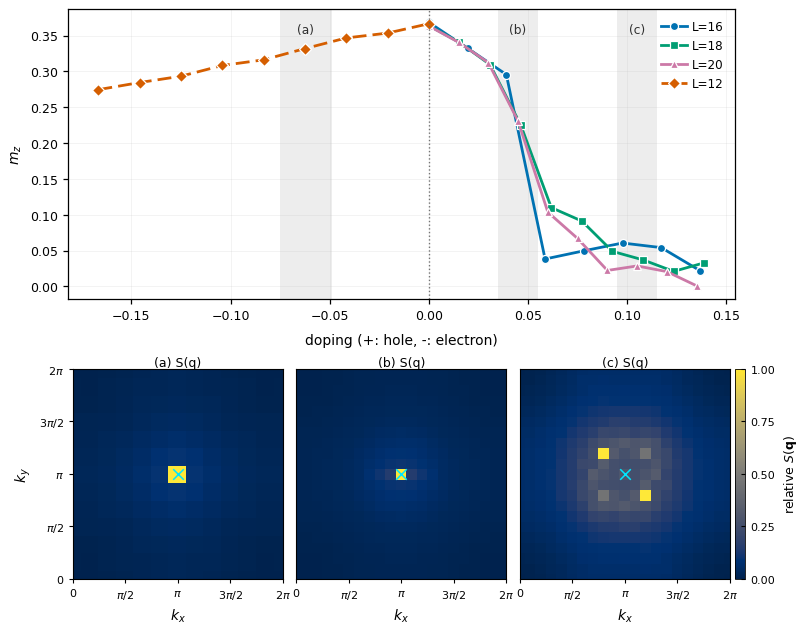

[OK] 输出 SVG: D:\study\研究生\科研\VMC\HKJ_s\mfVMC\results\picture2_from_notebook.svg
[OK] 输出 PDF: D:\study\研究生\科研\VMC\HKJ_s\mfVMC\results\picture2_from_notebook.pdf


In [57]:
module_path = project_root / 'plot/plot_abs_staggered_mz_bipolar_simple.py'
if not module_path.is_file():
    raise FileNotFoundError(f'找不到脚本文件: {module_path}')
spec = importlib.util.spec_from_file_location('plot_abs_staggered_mz_bipolar_simple', module_path)
if spec is None or spec.loader is None:
    raise ImportError(f'无法创建模块加载器: {module_path}')
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
collect_series_data = module.collect_series_data
all_series = collect_series_data(
    hole_series_inputs=hole_series_inputs,
    electron_series_inputs=electron_series_inputs,
    doping_col=doping_col,
    ndefect_col=ndefect_col,
    staggered_mz_col=mz_col,
    summary_name=summary_name,
)
sq_maps = []
for panel_config in sq_panel_configs:
    ss_json_path = Path(panel_config['ss_json_path']).resolve()
    lattice_size = int(panel_config['lattice_size'])
    if not ss_json_path.is_file():
        raise FileNotFoundError(f'S(q)数据文件不存在: {ss_json_path}')
    grid_kx, grid_ky, sq_map = compute_structure_factor_map(
        ss_all_json_path=ss_json_path,
        lattice_x=lattice_size,
        lattice_y=lattice_size,
        chunk_size=sq_chunk_size,
    )
    sq_min = float(np.min(sq_map))
    sq_max = float(np.max(sq_map))
    sq_span = sq_max - sq_min
    if np.isclose(sq_span, 0.0):
        sq_map_relative = np.zeros_like(sq_map)
    else:
        sq_map_relative = (sq_map - sq_min) / sq_span
    sq_maps.append((grid_kx, grid_ky, sq_map_relative))
figure = plt.figure(figsize=(figure_width, figure_height), constrained_layout=False)
grid_spec = figure.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[main_row_ratio, sq_row_ratio],
    hspace=layout_hspace,
    wspace=layout_wspace,
)
axis_main = figure.add_subplot(grid_spec[0, :])
# 主曲线
for series_label, doping_type, x_values, y_values in all_series:
    default_style = {'color': '#444444', 'marker': 'o'}
    curve_style = curve_style_map.get(series_label, default_style)
    line_style = hole_linestyle if doping_type == 'hole' else electron_linestyle
    axis_main.plot(
        x_values,
        y_values,
        marker=curve_style['marker'],
        linestyle=line_style,
        linewidth=main_linewidth,
        markersize=main_markersize,
        color=curve_style['color'],
        markerfacecolor=curve_style['color'],
        markeredgecolor=main_marker_edgecolor,
        markeredgewidth=main_marker_edgewidth,
        label=series_label,
    )
axis_main.axvline(
    0.0,
    color=main_vline_color,
    linestyle=main_vline_linestyle,
    linewidth=main_vline_linewidth,
    alpha=main_vline_alpha,
)
axis_main.set_xlabel('doping (+: hole, -: electron)', fontsize=main_label_fontsize, labelpad=main_xlabel_pad)
axis_main.set_ylabel(r'$m_z$', fontsize=main_label_fontsize)
axis_main.grid(color=main_grid_color, alpha=main_grid_alpha, linewidth=main_grid_linewidth)
axis_main.tick_params(
    axis='both',
    width=main_tick_width,
    length=main_tick_length,
    labelsize=main_tick_labelsize,
)
for one_spine in axis_main.spines.values():
    one_spine.set_linewidth(main_spine_linewidth)
# 在主图添加doping区间阴影, 用于与下方S(q)子图建立编号映射
y_min, y_max = axis_main.get_ylim()
zone_text_y = y_max - zone_label_offset_ratio * (y_max - y_min)
for panel_config in sq_panel_configs:
    x_start, x_end = panel_config['doping_range']
    axis_main.axvspan(
        float(x_start),
        float(x_end),
        color=zone_fill_color,
        alpha=zone_fill_alpha,
        zorder=0,
        lw=0.0,
    )
    axis_main.text(
        0.5 * (float(x_start) + float(x_end)),
        zone_text_y,
        panel_config['panel_tag'],
        ha='center',
        va='top',
        fontsize=zone_label_fontsize,
        color=zone_label_color,
    )
axis_main.legend(
    frameon=False,
    fontsize=main_legend_fontsize,
    loc='upper right',
    handlelength=2.2,
    handletextpad=0.4,
)
# 底部三张并排S(q), 共享ky轴
sq_axes = []
contour_artist = None
for panel_index, panel_config in enumerate(sq_panel_configs):
    axis_sq = figure.add_subplot(grid_spec[1, panel_index])
    sq_axes.append(axis_sq)
    grid_kx, grid_ky, sq_map_relative = sq_maps[panel_index]
    # 离散块绘制: 半格偏移边界 + 周期补一圈, 保证(pi,pi)落在色块中心
    lattice_size = int(sq_map_relative.shape[0])
    delta_k = 2.0 * np.pi / float(lattice_size)
    # 周期补一圈, 让0和2pi端点处色块连续
    sq_map_periodic = np.pad(sq_map_relative, ((0, 1), (0, 1)), mode='wrap')
    # 边界从 -dk/2 到 2pi+dk/2, 对应中心点 0, dk, ..., 2pi
    k_edges = np.linspace(-0.5 * delta_k, 2.0 * np.pi + 0.5 * delta_k, lattice_size + 2)
    edge_kx, edge_ky = np.meshgrid(k_edges, k_edges, indexing='ij')
    contour_artist = axis_sq.pcolor(
        edge_kx,
        edge_ky,
        sq_map_periodic,
        cmap=sq_cmap,
        vmin=0.0,
        vmax=1.0,
        edgecolors='none',
        antialiased=False,
    )
    axis_sq.scatter(
        np.pi,
        np.pi,
        c=sq_peak_marker_color,
        marker='x',
        s=sq_peak_marker_size,
        linewidths=sq_peak_marker_linewidth,
        zorder=4,
    )
    axis_sq.set_xlim(0.0, 2.0 * np.pi)
    axis_sq.set_ylim(0.0, 2.0 * np.pi)
    axis_sq.set_aspect('equal', adjustable='box')
    axis_sq.set_xlabel(r'$k_x$', fontsize=main_label_fontsize)
    axis_sq.set_title(f"{panel_config['panel_tag']} {panel_config['panel_label']}", fontsize=sq_title_fontsize, pad=sq_title_pad)
    apply_pi_ticks(axis_sq, max_k=2.0 * np.pi, show_y_ticklabels=(panel_index == 0))
    axis_sq.tick_params(
        axis='x',
        width=sq_tick_width,
        length=sq_tick_length,
        labelsize=sq_tick_labelsize,
    )
    if panel_index == 0:
        axis_sq.set_ylabel(r'$k_y$', fontsize=main_label_fontsize)
        axis_sq.tick_params(
            axis='y',
            labelleft=True,
            left=True,
            width=sq_tick_width,
            length=sq_tick_length,
            labelsize=sq_tick_labelsize,
        )
    else:
        axis_sq.tick_params(axis='y', labelleft=False, left=False)
    for one_spine in axis_sq.spines.values():
        one_spine.set_linewidth(sq_spine_linewidth)
# colorbar贴在最右侧S(q)旁边, 去掉右侧大空白
if contour_artist is None:
    raise RuntimeError('S(q)绘制失败: contour对象为空')
last_sq_pos = sq_axes[-1].get_position()
axis_cbar = figure.add_axes([
    last_sq_pos.x1 + colorbar_relative_pad,
    last_sq_pos.y0,
    colorbar_relative_width,
    last_sq_pos.height,
])
colorbar = figure.colorbar(contour_artist, cax=axis_cbar)
colorbar_ticks = np.linspace(0.0, 1.0, int(colorbar_tick_count))
colorbar.set_ticks(colorbar_ticks)
colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter(colorbar_tick_format))
colorbar.set_label(colorbar_label, fontsize=colorbar_label_fontsize, labelpad=colorbar_label_pad)
colorbar.ax.tick_params(
    labelsize=sq_tick_labelsize,
    width=sq_tick_width,
    length=sq_tick_length,
    direction='in',
)
colorbar.outline.set_linewidth(colorbar_outline_linewidth)
figure.savefig(output_svg, format='svg')
figure.savefig(output_pdf, format='pdf')
plt.show()
plt.close(figure)
print(f'[OK] 输出 SVG: {output_svg}')
print(f'[OK] 输出 PDF: {output_pdf}')
